In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')

In [9]:
df = pd.read_csv('D:\Ayush\ZyNova Solution Internship\MACHINE LEARNING RE 2026\Logistic Regression\Project - Customer Churn Prediction\Data\WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.shape

(7043, 21)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
df['customerID'].unique()

array(['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', ..., '4801-JZAZL',
       '8361-LTMKD', '3186-AJIEK'], dtype=object)

In [14]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [15]:
df.drop(columns = ['customerID'], inplace=True)  ## Remove column from the database

In [16]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [18]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [19]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [20]:
df['SeniorCitizen'].unique()

array([0, 1], dtype=int64)

In [21]:
for col in df.columns:
    if col not in ['tenure', 'MonthlyCharges', 'TotalCharges']:
        print(col, df[col].unique())
        print("------------------------")

gender ['Female' 'Male']
------------------------
SeniorCitizen [0 1]
------------------------
Partner ['Yes' 'No']
------------------------
Dependents ['No' 'Yes']
------------------------
PhoneService ['No' 'Yes']
------------------------
MultipleLines ['No phone service' 'No' 'Yes']
------------------------
InternetService ['DSL' 'Fiber optic' 'No']
------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
------------------------
TechSupport ['No' 'Yes' 'No internet service']
------------------------
StreamingTV ['No' 'Yes' 'No internet service']
------------------------
StreamingMovies ['No' 'Yes' 'No internet service']
------------------------
Contract ['Month-to-month' 'One year' 'Two year']
------------------------
PaperlessBilling ['Yes' 'No']
------------------------
PaymentMethod ['Electronic check' 'Mailed che

In [22]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [23]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    print(col, len(df[df[col] == " "]))
    print("-----------------------------")

tenure 0
-----------------------------
MonthlyCharges 0
-----------------------------
TotalCharges 11
-----------------------------


In [24]:
## In the 'TotalCharges' columne there are 11 Blank Space so remvoe That replace with 0.0

df['TotalCharges'] = df['TotalCharges'].replace({" ": "0.0"}).astype(float)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [26]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    print(col, len(df[df[col] == " "]))
    print("-----------------------------")

tenure 0
-----------------------------
MonthlyCharges 0
-----------------------------
TotalCharges 0
-----------------------------


In [27]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

- EDA - Exploraty Data Analysis

In [28]:
df.shape

(7043, 20)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [30]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [32]:
def plot_distribution(df, column_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[column_name], kde=True)
    plt.title(f"Distribution of {column_name}")

    col_mean = df[column_name].mean()
    col_median = df[column_name].median()
    plt.axvline(col_mean, color='red', linestyle="--", label="Mean")
    plt.axvline(col_median, color="blue", linestyle="--", label="Median")

    plt.legend()

    plt.subplot(1, 2, 2)
    sns.boxplot(y = df[column_name])
    plt.title(f"Boxplot Of {column_name}")
    plt.xlabel
    plt.ylabel
    plt.show()

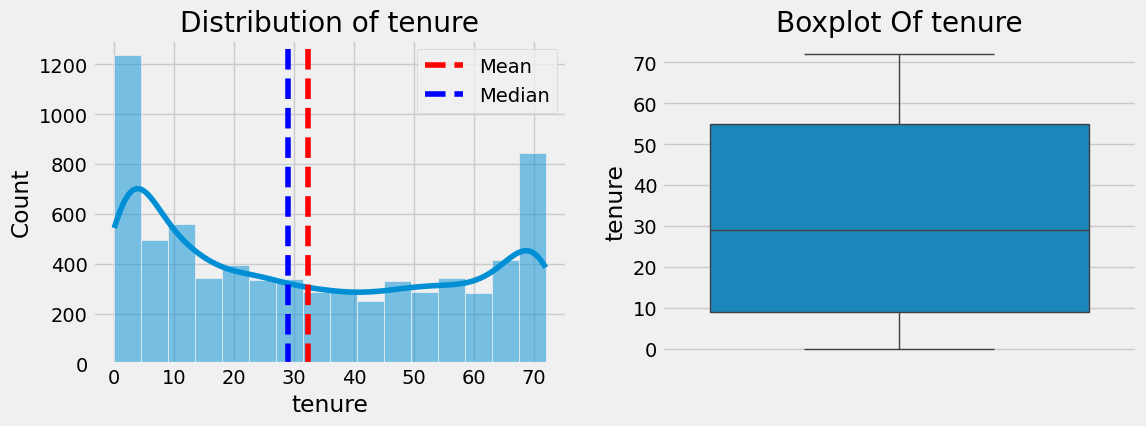

In [33]:
plot_distribution(df, "tenure")

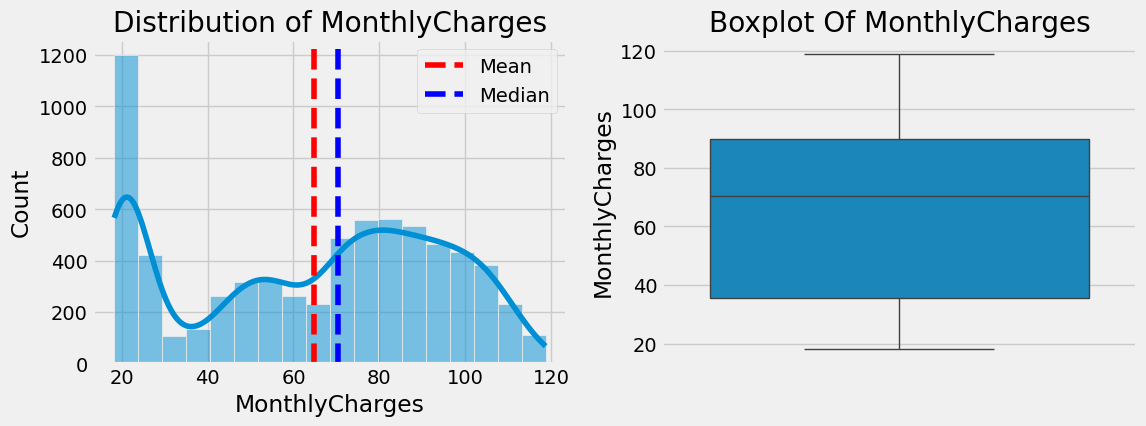

In [34]:
plot_distribution(df, 'MonthlyCharges')

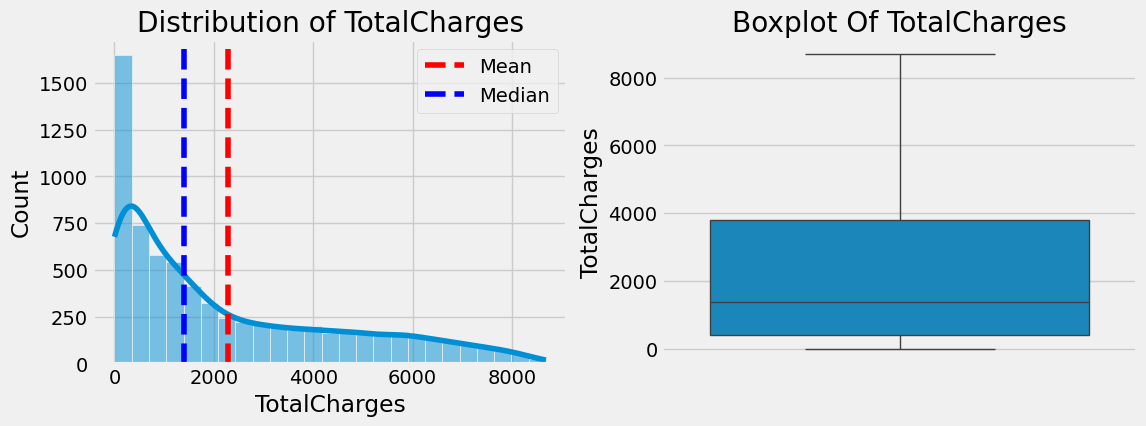

In [35]:
plot_distribution(df, 'TotalCharges')

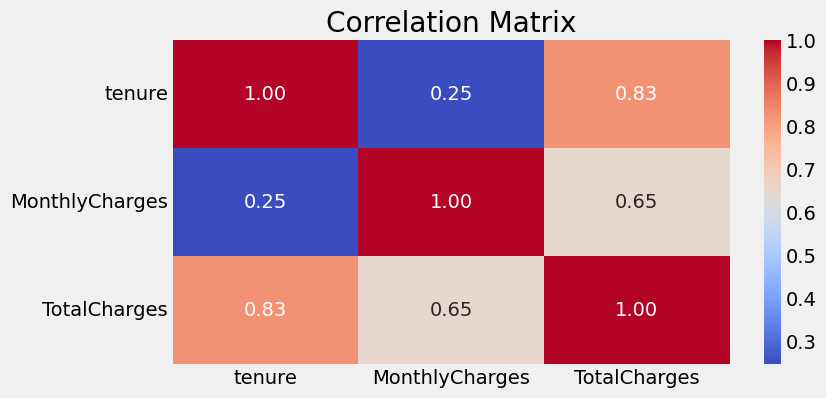

In [36]:
plt.figure(figsize=(8,4)) ## Width = 8, and height = 4
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()


# | Parameter         | Meaning                              |
# | ----------------- | ------------------------------------ |
# | `annot=True`      | Show correlation values inside cells |
# | `cmap='coolwarm'` | Red = positive, Blue = negative      |
# | `fmt='.2f'`       | Show values with 2 decimal places    |


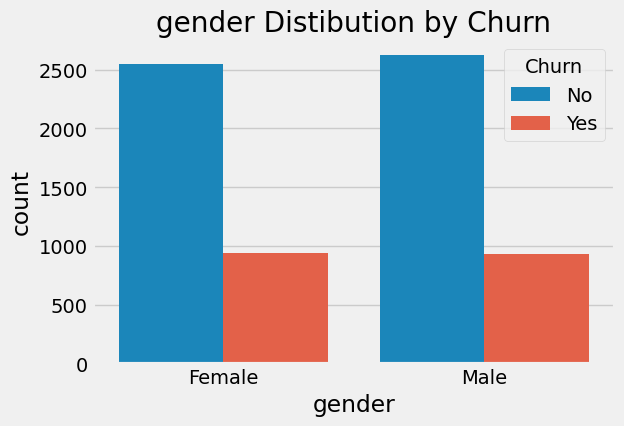

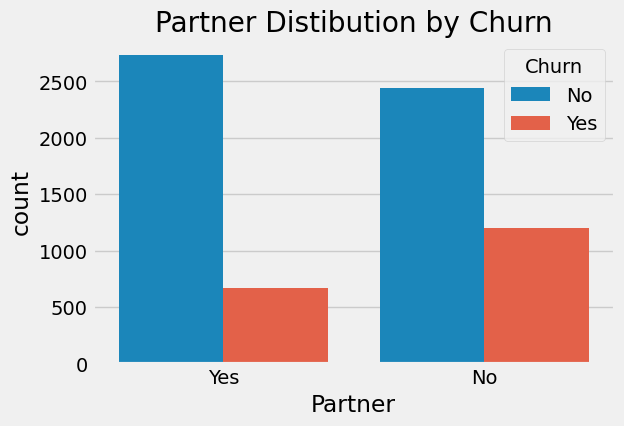

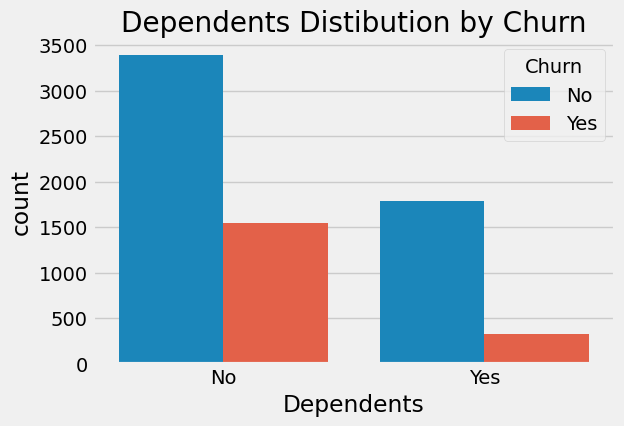

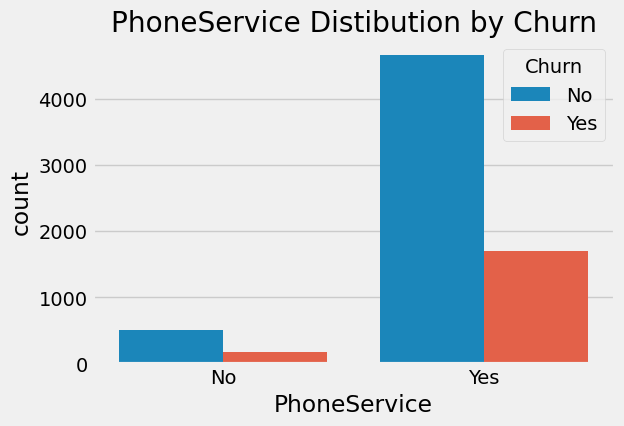

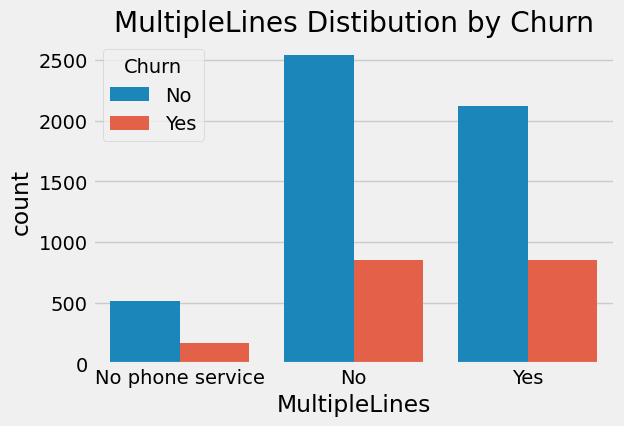

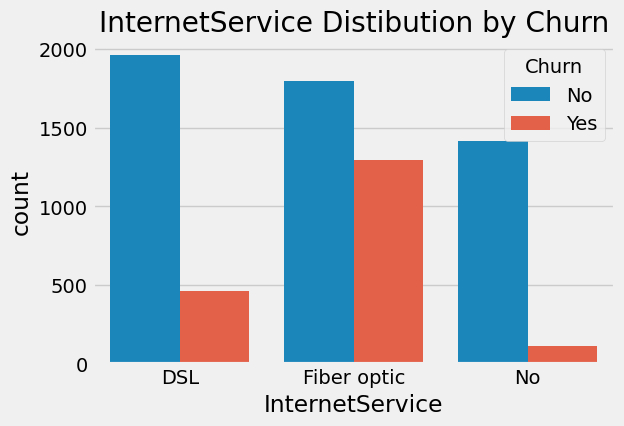

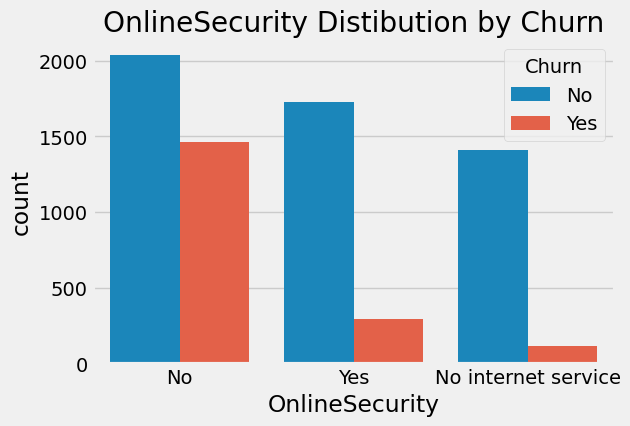

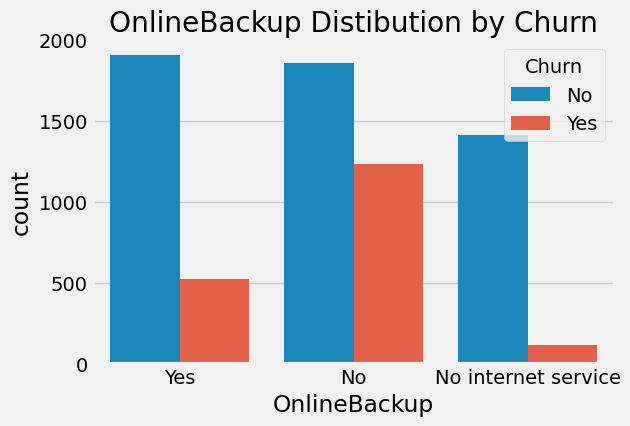

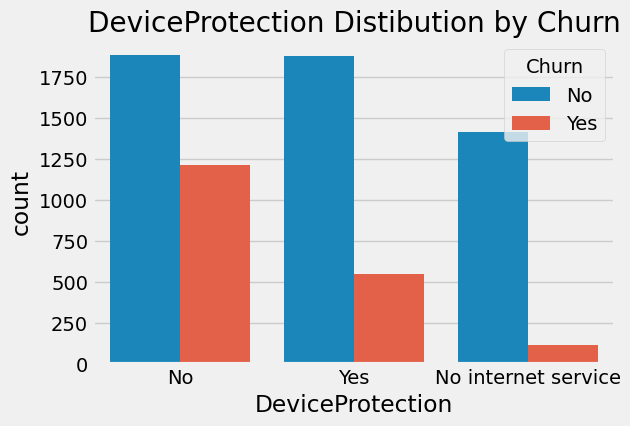

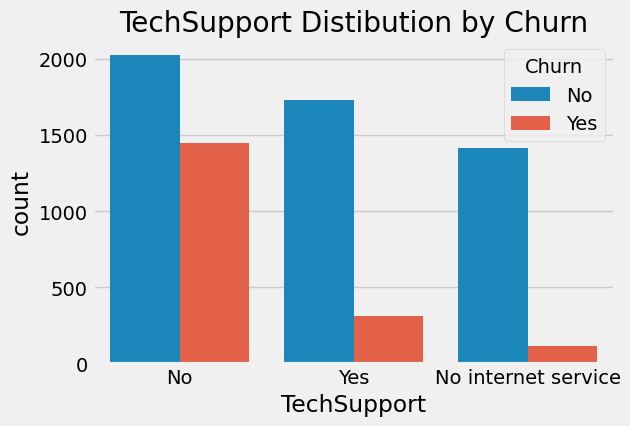

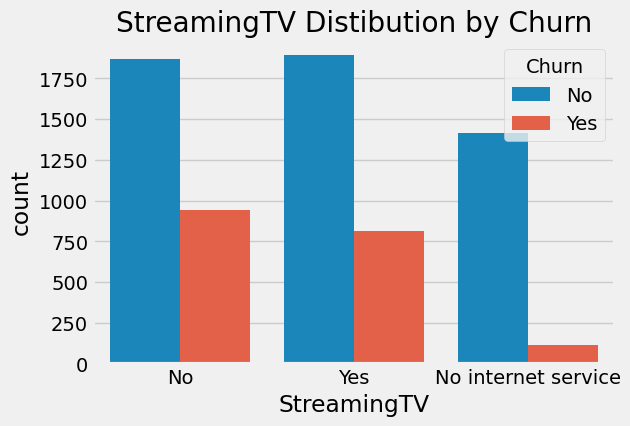

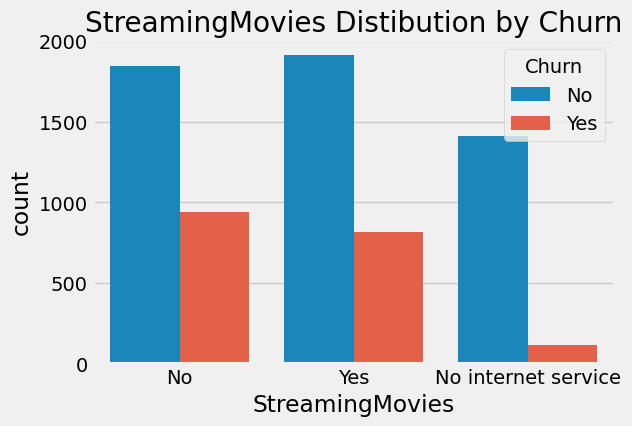

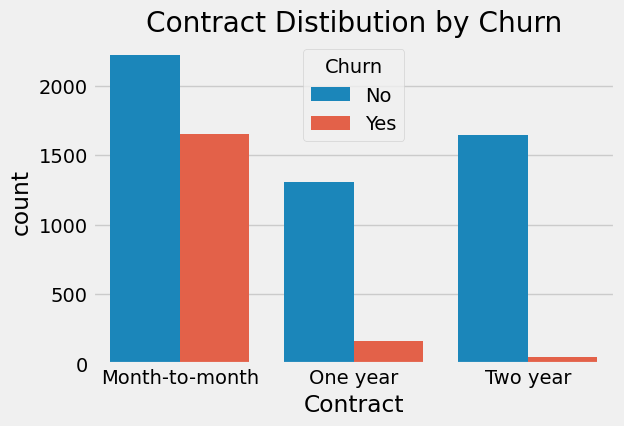

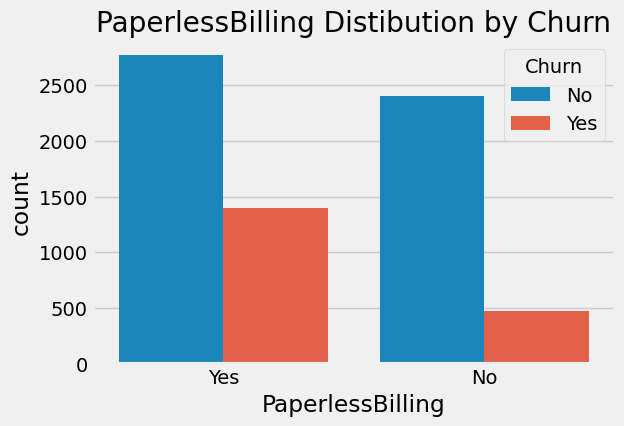

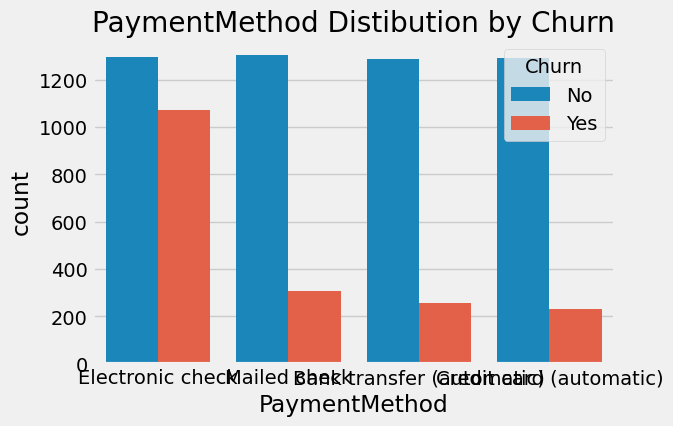

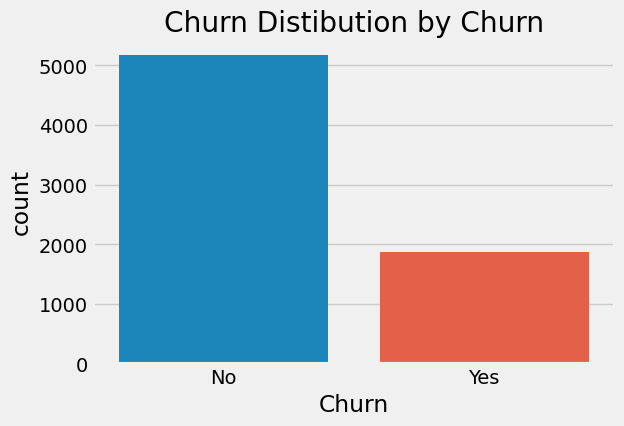

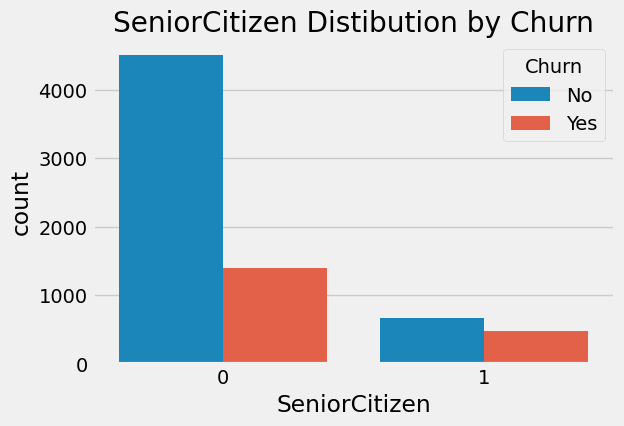

In [37]:
categorical_cols = df.select_dtypes(include="object").columns.to_list() + ['SeniorCitizen']

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data = df, x = col, hue='Churn')
    plt.title(f"{col} Distibution by Churn")
    plt.show()

- Label Encoding

In [38]:
df['Churn'] = df['Churn'].replace({"Yes": 1, "No": 0})

C:\Users\R_SQURE\AppData\Local\Temp\ipykernel_22792\196801821.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({"Yes": 1, "No": 0})


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [40]:
objects_columns = df.select_dtypes(include= "object").columns

In [41]:
objects_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [42]:
from sklearn.preprocessing import LabelEncoder

In [43]:
encoders = {}

for column in objects_columns:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder

In [44]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [45]:
df['gender'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: gender
Non-Null Count  Dtype
--------------  -----
7043 non-null   int32
dtypes: int32(1)
memory usage: 27.6 KB


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int32  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int32  
 3   Dependents        7043 non-null   int32  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int32  
 6   MultipleLines     7043 non-null   int32  
 7   InternetService   7043 non-null   int32  
 8   OnlineSecurity    7043 non-null   int32  
 9   OnlineBackup      7043 non-null   int32  
 10  DeviceProtection  7043 non-null   int32  
 11  TechSupport       7043 non-null   int32  
 12  StreamingTV       7043 non-null   int32  
 13  StreamingMovies   7043 non-null   int32  
 14  Contract          7043 non-null   int32  
 15  PaperlessBilling  7043 non-null   int32  
 16  PaymentMethod     7043 non-null   int32  


- Encoder Model Download

In [47]:
import pickle

In [48]:
with open("encoder.pkl", "wb") as f:
    pickle.dump(encoders, f)

- Scaler

In [49]:
from sklearn.preprocessing import StandardScaler

In [50]:
numerical_cols = ['tenure', 'MonthlyCharges','TotalCharges']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [51]:
numerical_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [52]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [53]:
X = df.drop(columns = ['Churn'])
y = df['Churn']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [55]:
# y_train.shape
y_train.value_counts()

Churn
0    4138
1    1496
Name: count, dtype: int64

In [56]:
smote = SMOTE(random_state=42)

In [57]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [58]:
y_train_smote.value_counts()

Churn
0    4138
1    4138
Name: count, dtype: int64

In [59]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [60]:
hyperparameters = {
    "Random Forest": {
        "n_estimators": [50,100,200],
        "max_depth": [5,10,None],
    },
    "XGBoost": {
        "learning_rate": [0.01,0.1,0.2],
        "max_depth": [3,5,7],
    }
}

In [61]:
best_models = {}

for model_name, model in models.items():
    print(f"Tunning {model_name}......")

    grid = GridSearchCV(estimator=model, param_grid=hyperparameters[model_name], cv=5, scoring="accuracy")
    grid.fit(X_train_smote, y_train_smote)
    best_models[model_name] = grid.best_estimator_

    print(f"Best Parameters For {model_name} : {grid.best_params_}")
    print(f"Best Accuracy For {model_name} : {grid.best_score_: .2f}\n" )

Tunning Random Forest......
Best Parameters For Random Forest : {'max_depth': None, 'n_estimators': 200}
Best Accuracy For Random Forest :  0.84

Tunning XGBoost......
Best Parameters For XGBoost : {'learning_rate': 0.2, 'max_depth': 7}
Best Accuracy For XGBoost :  0.82



In [62]:
best_models

{'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.2, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...)}

In [63]:
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_models['Random Forest'], f)

In [64]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [65]:
best_model = best_models["Random Forest"]
y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]))


## the output is explain on this link "https://chatgpt.com/s/t_69843949aad08191a98a350216293e18"


[[855 181]
 [125 248]]
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1036
           1       0.58      0.66      0.62       373

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.73      1409
weighted avg       0.79      0.78      0.79      1409

ROC AUC: 0.8330439305640377


In [66]:
best_model = best_models["XGBoost"]
y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]))

[[842 194]
 [124 249]]
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1036
           1       0.56      0.67      0.61       373

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.77      0.78      1409

ROC AUC: 0.8311587152069726


- Predict Training Data

In [67]:
y_test_pred = best_models['Random Forest'].predict(X_test)
y_test_prob = best_models['Random Forest'].predict_proba(X_test)[:,1]

In [68]:
y_test_pred

array([1, 0, 0, ..., 0, 0, 0], dtype=int64)

In [69]:
y_test_prob

array([0.915, 0.31 , 0.005, ..., 0.01 , 0.02 , 0.37 ])

In [70]:
print(f"Accuracy: ", accuracy_score(y_test, y_test_pred))
print(f"ROC - AUC Score: ", roc_auc_score(y_test, y_test_pred))
print(f"Confusion Matrix: \n", confusion_matrix(y_test, y_test_pred))
print(f"Classification Report: \n ", classification_report(y_test, y_test_pred))

Accuracy:  0.7828246983676366
ROC - AUC Score:  0.7450844659289699
Confusion Matrix: 
 [[855 181]
 [125 248]]
Classification Report: 
                precision    recall  f1-score   support

           0       0.87      0.83      0.85      1036
           1       0.58      0.66      0.62       373

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.73      1409
weighted avg       0.79      0.78      0.79      1409



In [71]:
with open("best_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
with open("encoder.pkl", "rb") as f:
    encoders = pickle.load(f)
with open("scaler.pkl", "rb") as f:
    scaler_data = pickle.load(f)

In [72]:
def make_prediction(input_data):
    input_df = pd.DataFrame([input_data])
    for col, encoder in encoders.items():
        input_df[col] = encoder.transform(input_df[col])
    numerical_cols = ['tenure','MonthlyCharges','TotalCharges']
    input_df[numerical_cols] = scaler_data.transform(input_df[numerical_cols])
    prediction = loaded_model.predict(input_df)[0]
    probability = loaded_model.predict_proba(input_df)[0,1]

    return "Churn" if prediction ==1 else "No Churn", probability

In [73]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [74]:
example_input = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 1,
    "PhoneService": "No",
    "MultipleLines": "No phone service",
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 29.85,
    "TotalCharges": 29.85
}


In [75]:
prediction, prob= make_prediction(example_input)

In [76]:
print(f"Prediction: {prediction}, Probability: {prob: .2f}")

Prediction: No Churn, Probability:  0.27
